# TFM · Predicción de Consumo y Precio Eléctrico — Madrid
## Notebook 02 · Análisis Exploratorio de Datos (EDA)

**Objetivo:** Comprender la estructura, patrones y relaciones del dataset antes de modelar.

**Secciones:**
1. Carga y descripción general del dataset
2. Análisis univariante — Precio eléctrico
3. Análisis univariante — Demanda eléctrica
4. Patrones temporales (horarios, diarios, estacionales)
5. Análisis de outliers
6. Análisis bivariante y correlaciones
7. Análisis de variables meteorológicas
8. Estacionalidad y descomposición de series temporales
9. Conclusiones del EDA

---
## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize':   (14, 4),
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})
COLORS  = ['#2563EB', '#F59E0B', '#10B981', '#EF4444', '#8B5CF6', '#EC4899']
CMAP    = 'RdYlGn_r'

print('✅ Setup completado')

✅ Setup completado


In [5]:
# ── Carga del dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('/dataset_base.csv')

# Leer con zona horaria UTC y convertir a Madrid directamente
df['datetime'] = pd.to_datetime(df['datetime'], utc=True).dt.tz_convert('Europe/Madrid')
df = df.dropna(subset=['datetime'])
df = df.set_index('datetime').sort_index()

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Período: {df.index.min().date()} → {df.index.max().date()}')
print(f'   Nulos totales: {df.isnull().sum().sum()}')
df.head(3)

✅ Dataset cargado: 26,284 filas × 24 columnas
   Período: 2023-01-01 → 2025-12-31
   Nulos totales: 25450


,hora,dia_semana,mes,semana_anio,anio,es_festivo,nombre_festivo,tipo_dia,dias_hasta_festivo,demanda_mw,...,irradiacion_wm2,nubosidad_pct,precipitacion_mm,precio_eur_kwh,hora_sin,hora_cos,dia_sin,dia_cos,mes_sin,mes_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+01:00,0,6,1,52,2023,False,NaN,domingo,5,240076.0,...,0.0,25.0,0.0,0.0,0.000000,1.000000,-0.781831,0.62349,0.5,0.866025
2023-01-01 01:00:00+01:00,1,6,1,52,2023,False,NaN,domingo,5,231504.0,...,0.0,20.0,0.0,0.0,0.258819,0.965926,-0.781831,0.62349,0.5,0.866025
2023-01-01 02:00:00+01:00,2,6,1,52,2023,False,NaN,domingo,5,217865.0,...,0.0,10.0,0.0,0.0,0.500000,0.866025,-0.781831,0.62349,0.5,0.866025


---
## 1. Descripción general del dataset

In [6]:
# ── Estadísticos descriptivos ──────────────────────────────────────────────────
cols_key = ['precio_eur_mwh', 'demanda_mw', 'temperatura_c',
            'humedad_pct', 'viento_kmh', 'irradiacion_wm2']
desc = df[cols_key].describe().round(2)
print('='*70)
print('ESTADÍSTICOS DESCRIPTIVOS — variables principales')
print('='*70)
print(desc)

# Coeficiente de variación (volatilidad relativa)
cv = (df[cols_key].std() / df[cols_key].mean() * 100).round(1)
print('\nCoeficiente de variación (%) — mayor = más volátil:')
print(cv.sort_values(ascending=False))

ESTADÍSTICOS DESCRIPTIVOS — variables principales
       precio_eur_mwh  demanda_mw  temperatura_c  humedad_pct  viento_kmh  \
count        26284.00    26284.00       26284.00     26278.00    26278.00   
mean            74.59   319346.90          15.96        59.29        9.78   
std             45.52    51480.44           9.22        25.75        6.09   
min             -5.00     3932.00          -4.30         5.00        0.00   
25%             36.00   277385.00           8.80        37.00        5.20   
50%             81.22   319370.00          14.80        61.00        8.50   
75%            109.02   356636.75          22.50        83.00       13.20   
max            240.00   477503.00          40.70       100.00       48.20   

       irradiacion_wm2  
count          26278.0  
mean             197.7  
std              277.3  
min                0.0  
25%                0.0  
50%               10.0  
75%              363.0  
max              988.0  

Coeficiente de variación (%) —

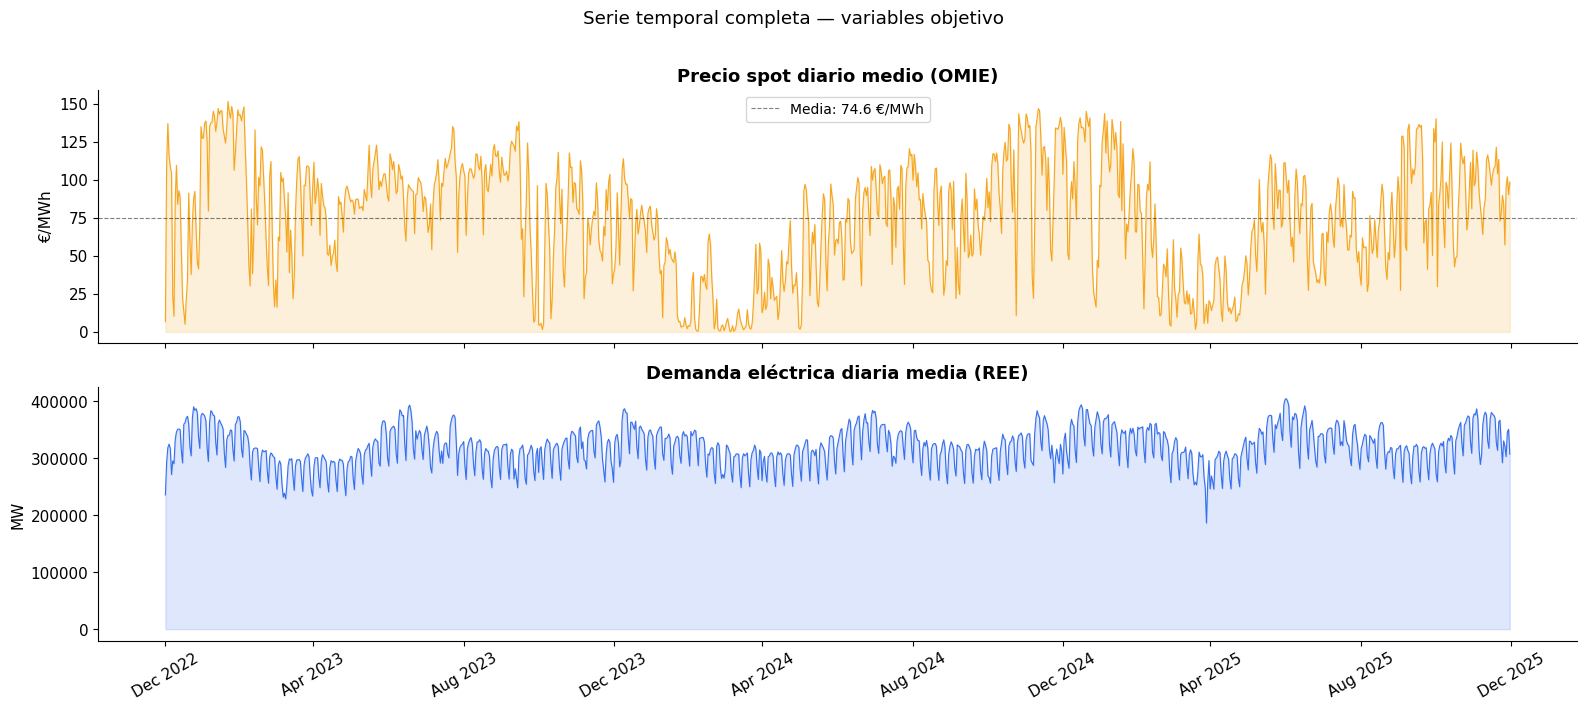

In [7]:
# ── Serie temporal completa de las dos variables target ────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('Serie temporal completa — variables objetivo', y=1.01)

diario = df[['precio_eur_mwh','demanda_mw']].resample('D').mean()

axes[0].plot(diario.index, diario['precio_eur_mwh'], color=COLORS[1], lw=0.8, alpha=0.9)
axes[0].fill_between(diario.index, diario['precio_eur_mwh'], alpha=0.15, color=COLORS[1])
axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precio spot diario medio (OMIE)')
axes[0].axhline(diario['precio_eur_mwh'].mean(), color='black', ls='--', lw=0.8, alpha=0.5,
                label=f'Media: {diario["precio_eur_mwh"].mean():.1f} €/MWh')
axes[0].legend(fontsize=10)

axes[1].plot(diario.index, diario['demanda_mw'], color=COLORS[0], lw=0.8, alpha=0.9)
axes[1].fill_between(diario.index, diario['demanda_mw'], alpha=0.15, color=COLORS[0])
axes[1].set_ylabel('MW')
axes[1].set_title('Demanda eléctrica diaria media (REE)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/eda_01_series_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Análisis univariante — Precio eléctrico (variable principal)

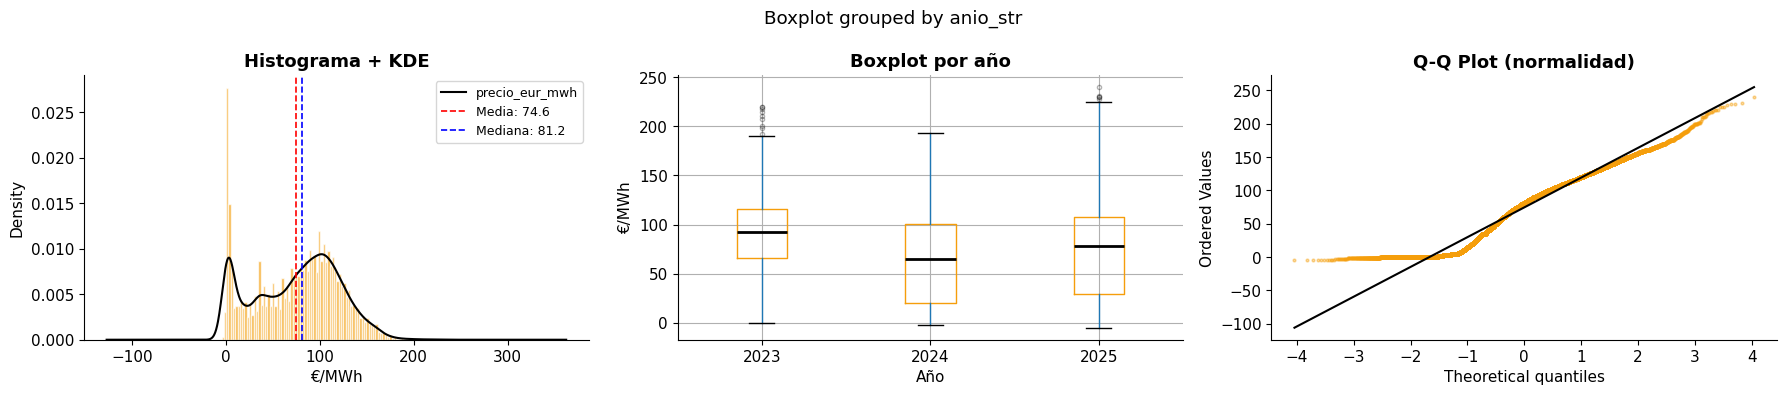

Asimetría (skewness): -0.116  →  negativa (cola izquierda)
Curtosis:             -0.867  →  platicúrtica
Test normalidad (D'Agostino-Pearson): p=0.00e+00  →  NO normal


In [8]:
precio = df['precio_eur_mwh']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribución del precio eléctrico horario', y=1.02)

# Histograma + KDE
axes[0].hist(precio, bins=100, color=COLORS[1], alpha=0.7, edgecolor='white', density=True)
precio.plot.kde(ax=axes[0], color='black', lw=1.5)
axes[0].axvline(precio.mean(),   color='red',  ls='--', lw=1.2, label=f'Media: {precio.mean():.1f}')
axes[0].axvline(precio.median(), color='blue', ls='--', lw=1.2, label=f'Mediana: {precio.median():.1f}')
axes[0].set_xlabel('€/MWh')
axes[0].set_title('Histograma + KDE')
axes[0].legend(fontsize=9)

# Boxplot por año
df['anio_str'] = df.index.year.astype(str)
df.boxplot(column='precio_eur_mwh', by='anio_str', ax=axes[1],
           boxprops=dict(color=COLORS[1]),
           medianprops=dict(color='black', lw=2),
           flierprops=dict(marker='.', alpha=0.3))
axes[1].set_title('Boxplot por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('€/MWh')
plt.sca(axes[1])
plt.title('Boxplot por año')

# Q-Q plot (normalidad)
stats.probplot(precio.dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normalidad)')
axes[2].get_lines()[0].set(color=COLORS[1], alpha=0.4, markersize=2)
axes[2].get_lines()[1].set(color='black', lw=1.5)

plt.tight_layout()
plt.savefig('/eda_02_precio_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# Test de normalidad
stat, p = stats.normaltest(precio.dropna())
skew    = precio.skew()
kurt    = precio.kurtosis()
print(f'Asimetría (skewness): {skew:.3f}  →  {"positiva (cola derecha)" if skew>0 else "negativa (cola izquierda)"}')
print(f'Curtosis:             {kurt:.3f}  →  {"leptocúrtica (colas pesadas)" if kurt>0 else "platicúrtica"}')
print(f"Test normalidad (D'Agostino-Pearson): p={p:.2e}  →  {'NO normal' if p<0.05 else 'Normal'}")

La asimetría es casi despreciable y las colas poco pesadas, por lo que la distribución es buena para poder realizar el resto del análisis. No obstante, destaca la alta densidad de precios alrededor del 0.

In [9]:
# ── Precios negativos — fenómeno relevante en el mercado eléctrico ─────────────
negativos = precio[precio < 0]
cero      = precio[precio == 0]

print('='*55)
print('ANÁLISIS DE PRECIOS NEGATIVOS Y CERO')
print('='*55)
print(f'Horas con precio negativo: {len(negativos):,} ({len(negativos)/len(precio)*100:.2f}%)')
print(f'Horas con precio = 0:      {len(cero):,} ({len(cero)/len(precio)*100:.2f}%)')
if len(negativos) > 0:
    print(f'Precio mínimo:             {negativos.min():.2f} €/MWh')
    print(f'\nDistribución por año:')
    print(negativos.groupby(negativos.index.year).count())
    print('\nDistribución por hora del día:')
    print(negativos.groupby(negativos.index.hour).count().sort_values(ascending=False).head(5))

ANÁLISIS DE PRECIOS NEGATIVOS Y CERO
Horas con precio negativo: 386 (1.47%)
Horas con precio = 0:      787 (2.99%)
Precio mínimo:             -5.00 €/MWh

Distribución por año:
datetime
2024    196
2025    190
Name: precio_eur_mwh, dtype: int64

Distribución por hora del día:
datetime
15    67
16    61
14    58
13    45
12    40
Name: precio_eur_mwh, dtype: int64


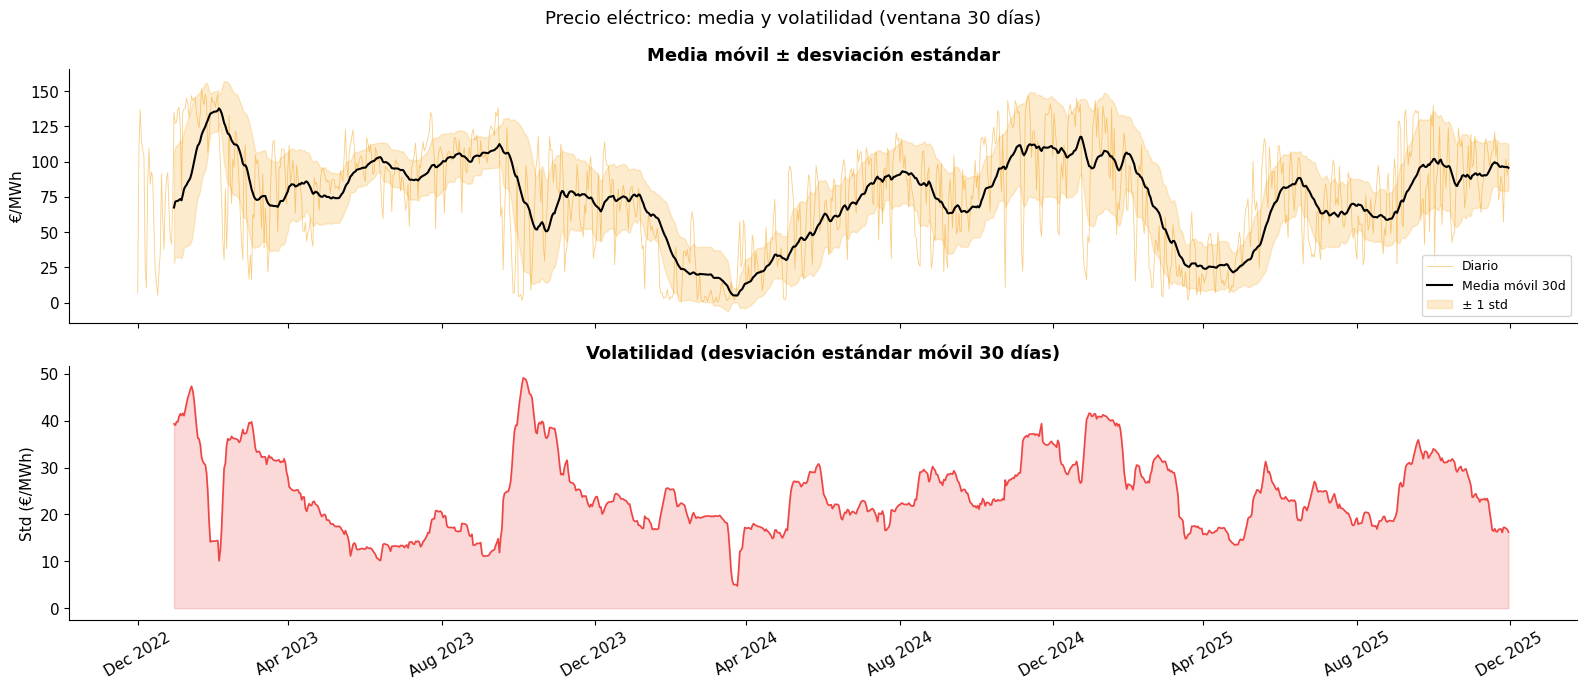

In [10]:
# ── Volatilidad del precio — rolling std ──────────────────────────────────────
precio_diario = precio.resample('D').mean()
rolling_std   = precio_diario.rolling(window=30).std()
rolling_mean  = precio_diario.rolling(window=30).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('Precio eléctrico: media y volatilidad (ventana 30 días)')

axes[0].plot(precio_diario.index, precio_diario.values, color=COLORS[1], lw=0.6, alpha=0.5, label='Diario')
axes[0].plot(rolling_mean.index, rolling_mean.values, color='black', lw=1.5, label='Media móvil 30d')
axes[0].fill_between(rolling_mean.index,
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     alpha=0.2, color=COLORS[1], label='± 1 std')
axes[0].set_ylabel('€/MWh')
axes[0].legend(fontsize=9)
axes[0].set_title('Media móvil ± desviación estándar')

axes[1].plot(rolling_std.index, rolling_std.values, color=COLORS[3], lw=1.2)
axes[1].fill_between(rolling_std.index, rolling_std.values, alpha=0.2, color=COLORS[3])
axes[1].set_ylabel('Std (€/MWh)')
axes[1].set_title('Volatilidad (desviación estándar móvil 30 días)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('/eda_03_precio_volatilidad.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Análisis univariante — Demanda eléctrica

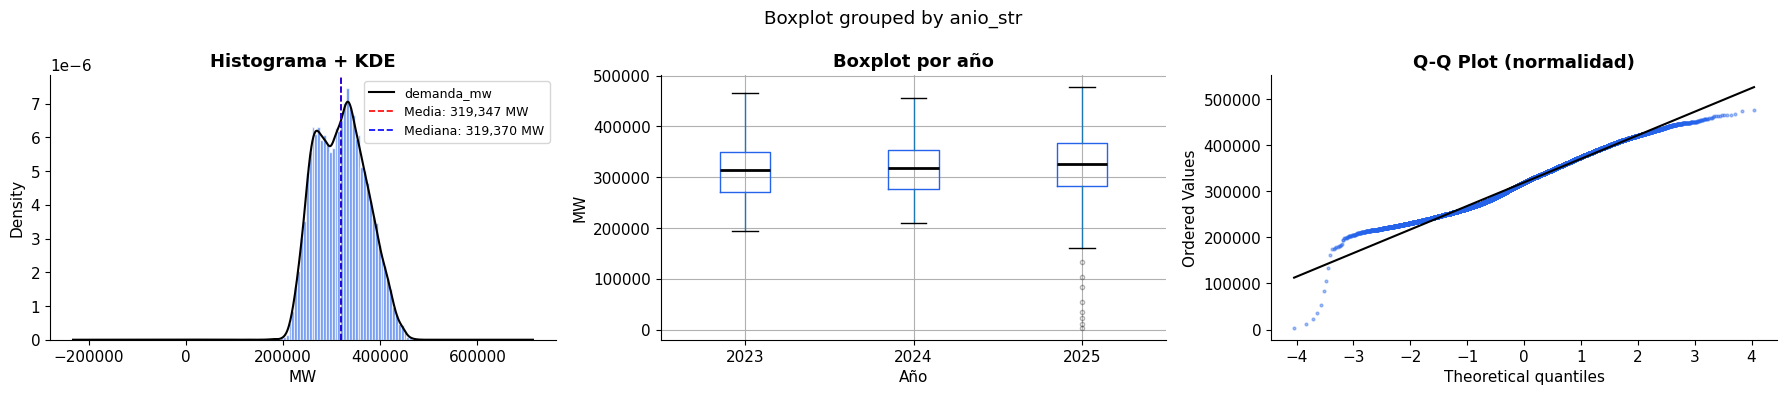

In [11]:
demanda = df['demanda_mw']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Distribución de la demanda eléctrica horaria', y=1.02)

axes[0].hist(demanda, bins=80, color=COLORS[0], alpha=0.7, edgecolor='white', density=True)
demanda.plot.kde(ax=axes[0], color='black', lw=1.5)
axes[0].axvline(demanda.mean(),   color='red',  ls='--', lw=1.2, label=f'Media: {demanda.mean():,.0f} MW')
axes[0].axvline(demanda.median(), color='blue', ls='--', lw=1.2, label=f'Mediana: {demanda.median():,.0f} MW')
axes[0].set_xlabel('MW')
axes[0].set_title('Histograma + KDE')
axes[0].legend(fontsize=9)

df.boxplot(column='demanda_mw', by='anio_str', ax=axes[1],
           boxprops=dict(color=COLORS[0]),
           medianprops=dict(color='black', lw=2),
           flierprops=dict(marker='.', alpha=0.3))
axes[1].set_title('Boxplot por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('MW')
plt.sca(axes[1]); plt.title('Boxplot por año')

stats.probplot(demanda.dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normalidad)')
axes[2].get_lines()[0].set(color=COLORS[0], alpha=0.4, markersize=2)
axes[2].get_lines()[1].set(color='black', lw=1.5)

plt.tight_layout()
plt.savefig('/eda_04_demanda_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Patrones temporales

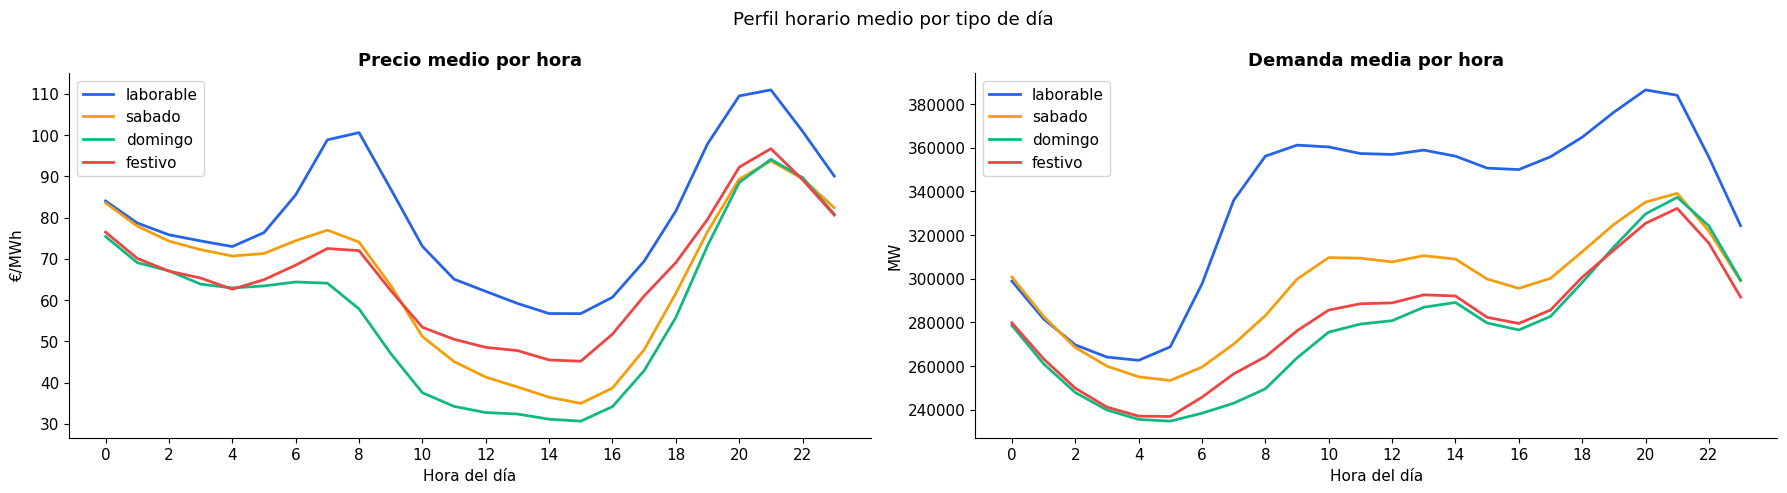

In [12]:
# ── Perfil horario medio por tipo de día ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Perfil horario medio por tipo de día')

tipos   = ['laborable', 'sabado', 'domingo', 'festivo']
colores = [COLORS[0], COLORS[1], COLORS[2], COLORS[3]]

for tipo, color in zip(tipos, colores):
    subset = df[df['tipo_dia'] == tipo]
    perfil_precio   = subset.groupby('hora')['precio_eur_mwh'].mean()
    perfil_demanda  = subset.groupby('hora')['demanda_mw'].mean()
    axes[0].plot(perfil_precio.index,  perfil_precio.values,  color=color, lw=2, label=tipo)
    axes[1].plot(perfil_demanda.index, perfil_demanda.values, color=color, lw=2, label=tipo)

axes[0].set_xlabel('Hora del día')
axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precio medio por hora')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend()

axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('MW')
axes[1].set_title('Demanda media por hora')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()

plt.tight_layout()
plt.savefig('/eda_05_perfil_horario.png', dpi=150, bbox_inches='tight')
plt.show()

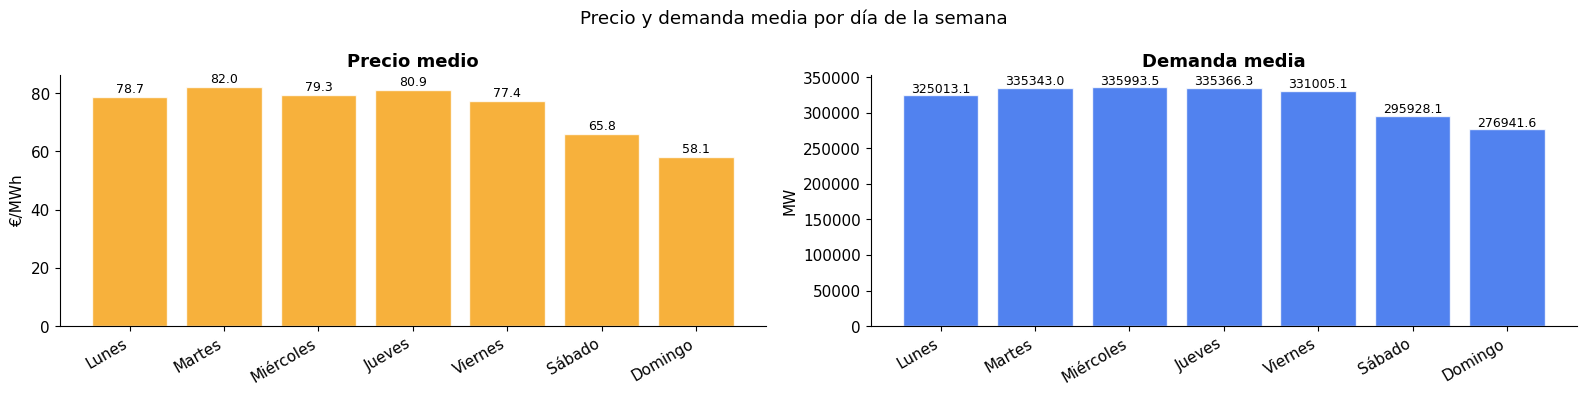

In [13]:
# ── Perfil semanal ─────────────────────────────────────────────────────────────
dias_nombre = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Precio y demanda media por día de la semana')

precio_semana  = df.groupby('dia_semana')['precio_eur_mwh'].mean()
demanda_semana = df.groupby('dia_semana')['demanda_mw'].mean()

bars0 = axes[0].bar(dias_nombre, precio_semana.values,  color=COLORS[1], alpha=0.8, edgecolor='white')
bars1 = axes[1].bar(dias_nombre, demanda_semana.values, color=COLORS[0], alpha=0.8, edgecolor='white')

for ax, bars in [(axes[0], bars0), (axes[1], bars1)]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticklabels(dias_nombre, rotation=30, ha='right')

axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precio medio')
axes[1].set_ylabel('MW')
axes[1].set_title('Demanda media')

plt.tight_layout()
plt.savefig('/eda_06_perfil_semanal.png', dpi=150, bbox_inches='tight')
plt.show()

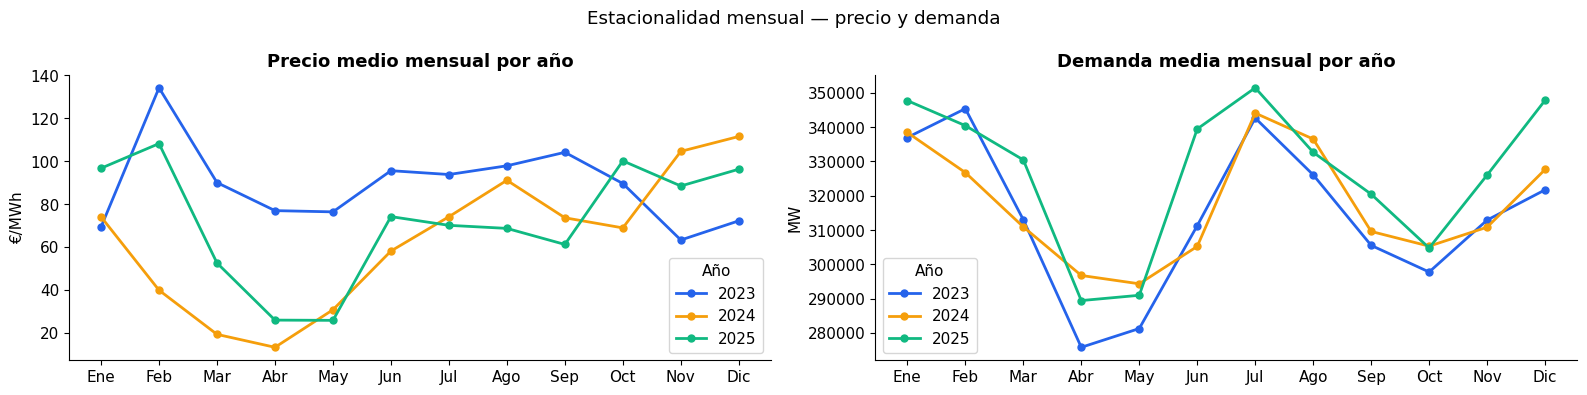

In [14]:
# ── Perfil mensual — estacionalidad anual ─────────────────────────────────────
meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Estacionalidad mensual — precio y demanda')

for anio, color in zip(sorted(df.index.year.unique()), COLORS):
    subset = df[df.index.year == anio]
    p_mes  = subset.groupby('mes')['precio_eur_mwh'].mean()
    d_mes  = subset.groupby('mes')['demanda_mw'].mean()
    axes[0].plot(p_mes.index, p_mes.values, color=color, lw=2, marker='o', ms=5, label=str(anio))
    axes[1].plot(d_mes.index, d_mes.values, color=color, lw=2, marker='o', ms=5, label=str(anio))

for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_nombre)
    ax.legend(title='Año')

axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precio medio mensual por año')
axes[1].set_ylabel('MW')
axes[1].set_title('Demanda media mensual por año')

plt.tight_layout()
plt.savefig('/eda_07_estacionalidad_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

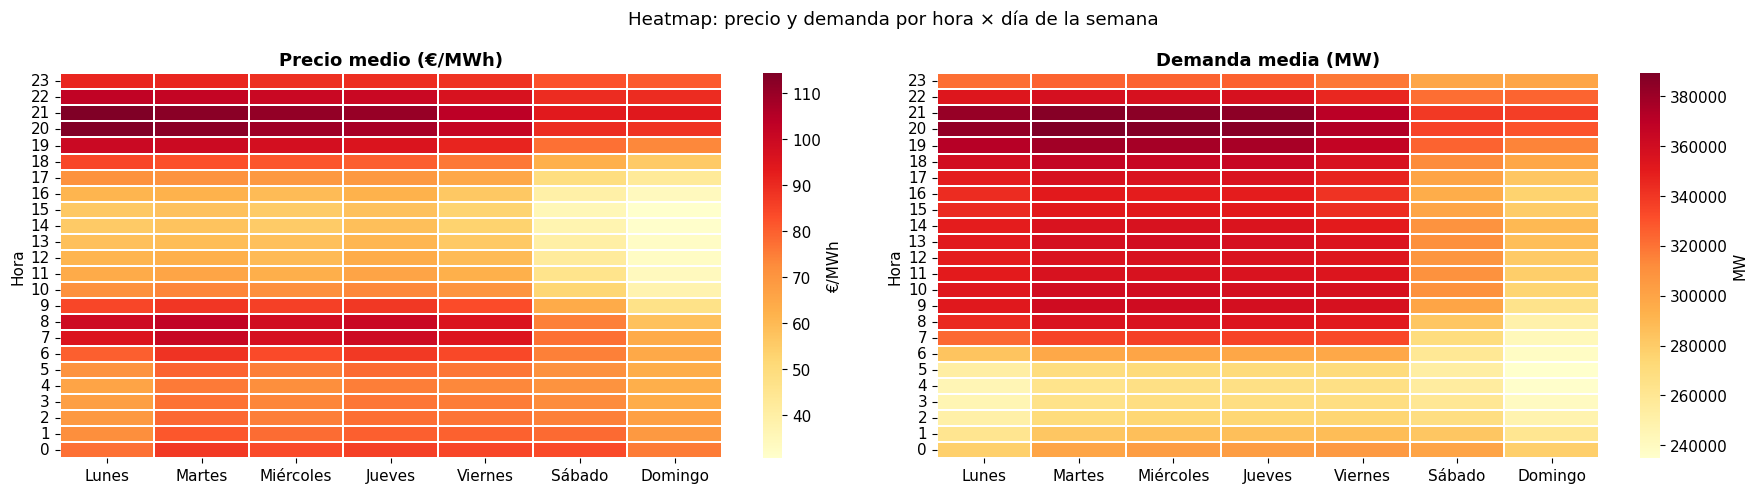

In [15]:
# ── Heatmap hora × día de la semana ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Heatmap: precio y demanda por hora × día de la semana')

pivot_precio  = df.pivot_table(values='precio_eur_mwh', index='hora', columns='dia_semana', aggfunc='mean')
pivot_demanda = df.pivot_table(values='demanda_mw',     index='hora', columns='dia_semana', aggfunc='mean')

pivot_precio.columns  = dias_nombre
pivot_demanda.columns = dias_nombre

sns.heatmap(pivot_precio,  ax=axes[0], cmap='YlOrRd',  annot=False, fmt='.0f',
            linewidths=0.3, cbar_kws={'label': '€/MWh'})
sns.heatmap(pivot_demanda, ax=axes[1], cmap='YlOrRd',  annot=False, fmt='.0f',
            linewidths=0.3, cbar_kws={'label': 'MW'})

axes[0].set_title('Precio medio (€/MWh)')
axes[1].set_title('Demanda media (MW)')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Hora')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/eda_08_heatmap_hora_dia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Análisis de outliers

In [16]:
# ── Detección de outliers con IQR y Z-score ───────────────────────────────────
def detectar_outliers(serie: pd.Series, nombre: str):
    # IQR
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_iqr = serie[(serie < lb) | (serie > ub)]

    # Z-score
    z = np.abs(stats.zscore(serie.dropna()))
    outliers_z = serie[z > 3]

    print(f'\n{nombre}')
    print(f'  IQR  → [{lb:.1f}, {ub:.1f}] | Outliers: {len(outliers_iqr):,} ({len(outliers_iqr)/len(serie)*100:.2f}%)')
    print(f'  Z>3  → Outliers: {len(outliers_z):,} ({len(outliers_z)/len(serie)*100:.2f}%)')
    print(f'  Percentil 99: {serie.quantile(0.99):.1f} | Percentil 1: {serie.quantile(0.01):.1f}')
    return outliers_iqr

print('='*55)
print('DETECCIÓN DE OUTLIERS')
print('='*55)
out_precio  = detectar_outliers(df['precio_eur_mwh'], 'Precio (€/MWh)')
out_demanda = detectar_outliers(df['demanda_mw'],     'Demanda (MW)')

DETECCIÓN DE OUTLIERS

Precio (€/MWh)
  IQR  → [-73.5, 218.6] | Outliers: 12 (0.05%)
  Z>3  → Outliers: 19 (0.07%)
  Percentil 99: 165.5 | Percentil 1: -0.0

Demanda (MW)
  IQR  → [158507.4, 475514.4] | Outliers: 9 (0.03%)
  Z>3  → Outliers: 11 (0.04%)
  Percentil 99: 432655.8 | Percentil 1: 222871.4


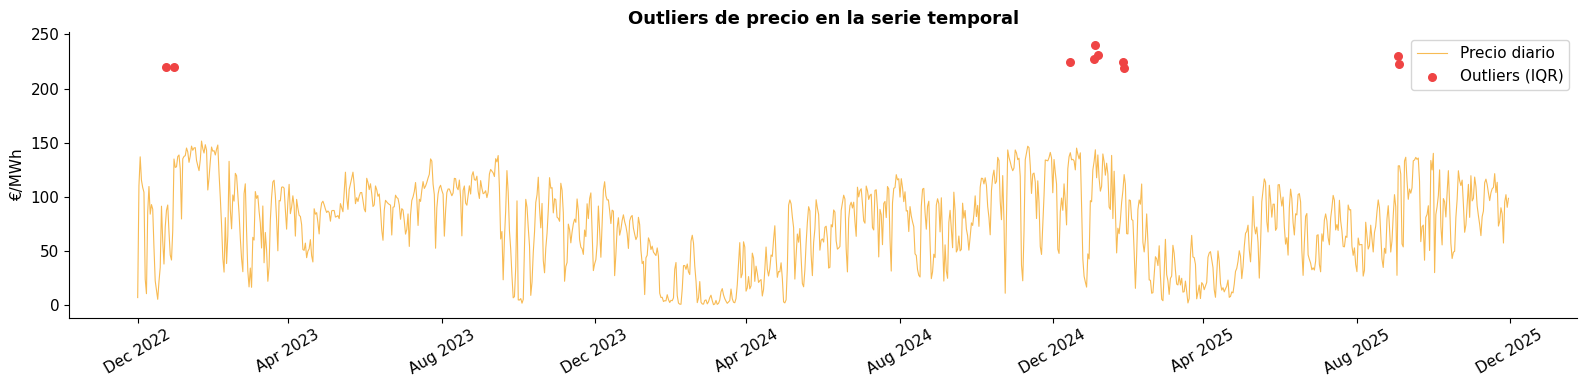

In [18]:
# ── Visualizar outliers de precio en la serie temporal ────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))

precio_diario = df['precio_eur_mwh'].resample('D').mean()
ax.plot(precio_diario.index, precio_diario.values, color=COLORS[1], lw=0.8, alpha=0.7, label='Precio diario')

# Marcar los días con outliers
dias_outlier = out_precio.resample('D').mean()
ax.scatter(dias_outlier.index, dias_outlier.values, color=COLORS[3], s=30, zorder=5, label='Outliers (IQR)')

ax.set_ylabel('€/MWh')
ax.set_title('Outliers de precio en la serie temporal')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('/eda_09_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

son pocos outliers y representan eventos reales, por lo que han de quedarse

---
## 6. Análisis bivariante y correlaciones

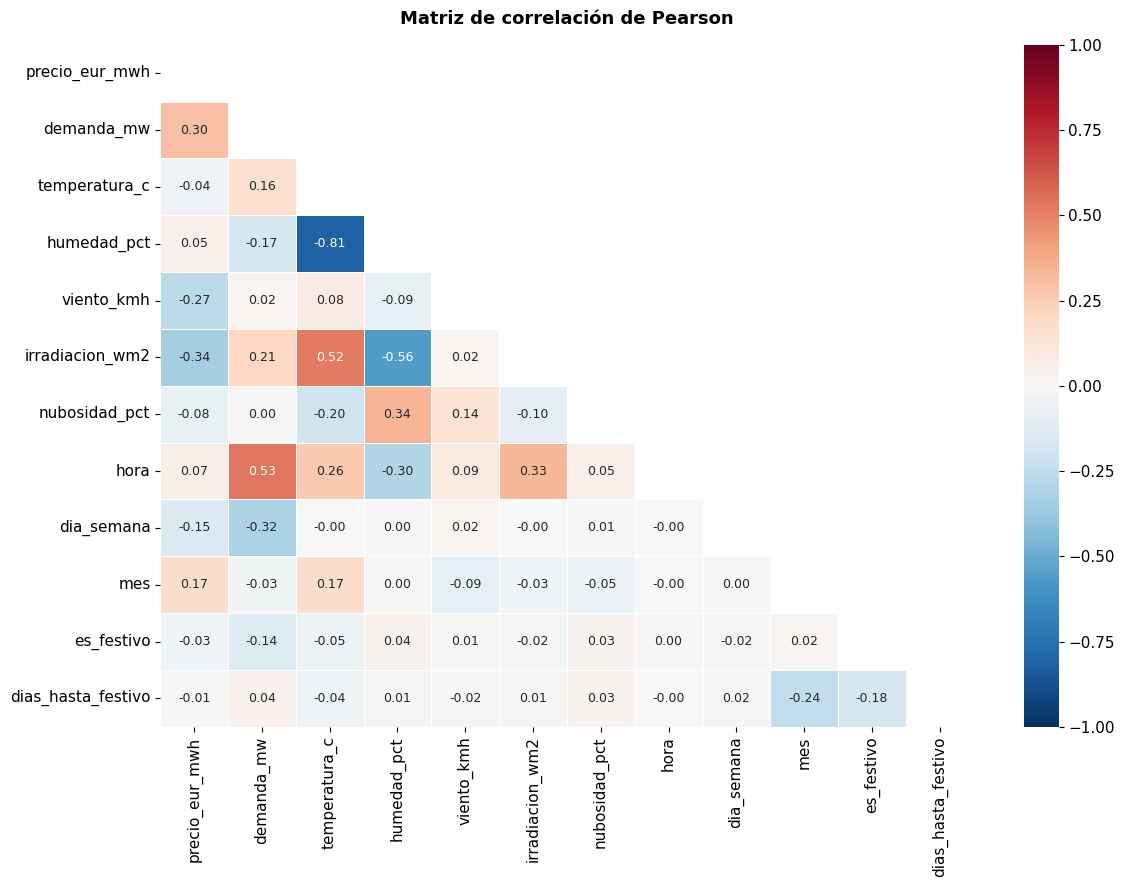


Top correlaciones con precio_eur_mwh:
irradiacion_wm2      -0.339
demanda_mw            0.298
viento_kmh           -0.272
mes                   0.172
dia_semana           -0.151
nubosidad_pct        -0.079
hora                  0.066
humedad_pct           0.050
temperatura_c        -0.044
es_festivo           -0.033
dias_hasta_festivo   -0.008
Name: precio_eur_mwh, dtype: float64


In [23]:
# ── Matriz de correlación ─────────────────────────────────────────────────────
cols_corr = ['precio_eur_mwh','demanda_mw','temperatura_c','humedad_pct',
             'viento_kmh','irradiacion_wm2','nubosidad_pct',
             'hora','dia_semana','mes','es_festivo','dias_hasta_festivo']

df_corr = df[cols_corr].copy()
df_corr['es_festivo'] = df_corr['es_festivo'].astype(int)

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9},
            vmin=-1, vmax=1)
ax.set_title('Matriz de correlación de Pearson', pad=15)
plt.tight_layout()
plt.savefig('/eda_10_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlaciones con precio
print('\nTop correlaciones con precio_eur_mwh:')
print(corr['precio_eur_mwh'].drop('precio_eur_mwh').sort_values(key=abs, ascending=False).round(3))

Dias hasta festivo tiene una correlacion infima, veamos si realmente aporta info o elimino.

In [35]:
# Ver si el efecto es no lineal — media de precio según días hasta festivo
efecto = df[df['dias_hasta_festivo'] <= 10].groupby('dias_hasta_festivo')['precio_eur_mwh'].mean()
print(efecto)

dias_hasta_festivo
0     66.369456
1     81.874972
2     80.769985
3     76.969406
4     72.286711
5     71.719520
6     72.874409
7     75.437627
8     81.972482
9     82.593134
10    80.127246
Name: precio_eur_mwh, dtype: float64


Vemos que afecta realmente al precio, asi que se queda. Además, voy a crear dos flags

In [36]:
df['es_vispera_festivo'] = (df['dias_hasta_festivo'] == 1).astype(int)

# Post-festivo: el día anterior era festivo Y hoy NO es festivo
es_festivo_int = df['es_festivo'].astype(int)
df['es_post_festivo'] = (
    (es_festivo_int.shift(24, fill_value=0) == 1) &  # ayer era festivo
    (es_festivo_int == 0)                             # hoy NO es festivo
).astype(int)

# Verificar
print('Precio medio por flag:')
print(f'  Día normal:          {df[(df["es_festivo"]==False) & (df["es_vispera_festivo"]==0) & (df["es_post_festivo"]==0)]["precio_eur_mwh"].mean():.1f} €/MWh')
print(f'  Festivo:             {df[df["es_festivo"]==True]["precio_eur_mwh"].mean():.1f} €/MWh')
print(f'  Víspera de festivo:  {df[df["es_vispera_festivo"]==1]["precio_eur_mwh"].mean():.1f} €/MWh')
print(f'  Post festivo:        {df[df["es_post_festivo"]==1]["precio_eur_mwh"].mean():.1f} €/MWh')

# Guardar
df.reset_index().to_csv('/dataset_base.csv', index=False)
print('\n✅ Dataset actualizado')

Precio medio por flag:
  Día normal:          74.9 €/MWh
  Festivo:             66.4 €/MWh
  Víspera de festivo:  81.9 €/MWh
  Post festivo:        67.2 €/MWh

✅ Dataset actualizado


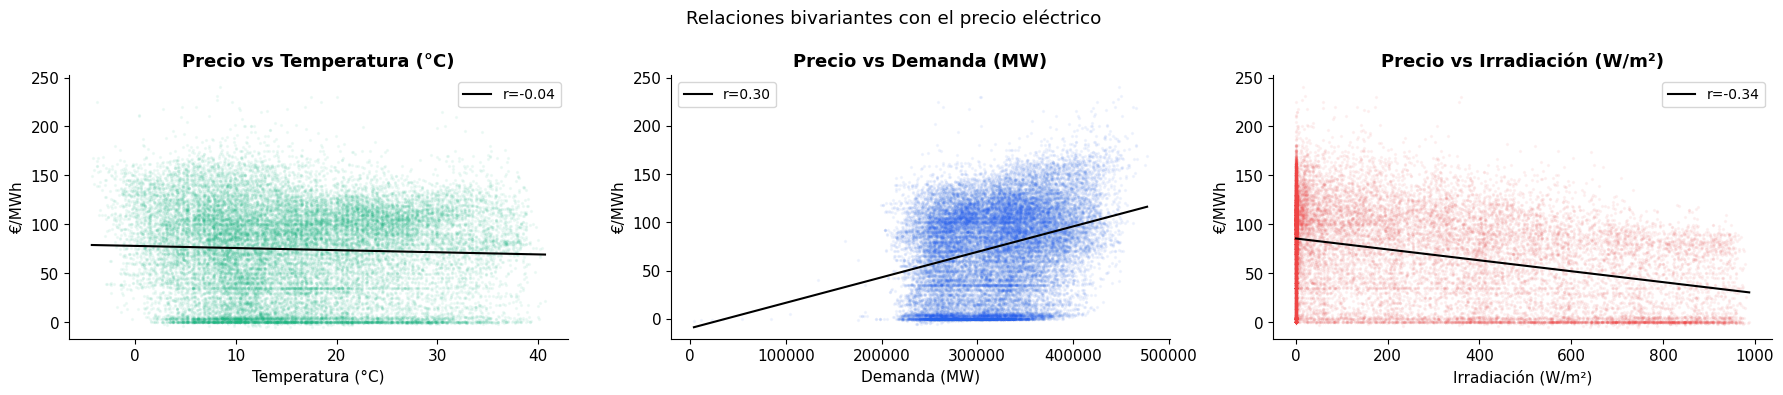

In [25]:
# ── Scatter precio vs temperatura y demanda ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Relaciones bivariantes con el precio eléctrico')

pares = [
    ('temperatura_c',   'Temperatura (°C)',    COLORS[2]),
    ('demanda_mw',      'Demanda (MW)',         COLORS[0]),
    ('irradiacion_wm2', 'Irradiación (W/m²)',  COLORS[3]),
]

for ax, (col, label, color) in zip(axes, pares):
    ax.scatter(df[col], df['precio_eur_mwh'],
               alpha=0.05, s=2, color=color)
    # Línea de tendencia
    m, b = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'precio_eur_mwh'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', lw=1.5, label=f'r={df[[col,"precio_eur_mwh"]].corr().iloc[0,1]:.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('€/MWh')
    ax.set_title(f'Precio vs {label}')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/eda_11_scatter_bivariante.png', dpi=150, bbox_inches='tight')
plt.show()

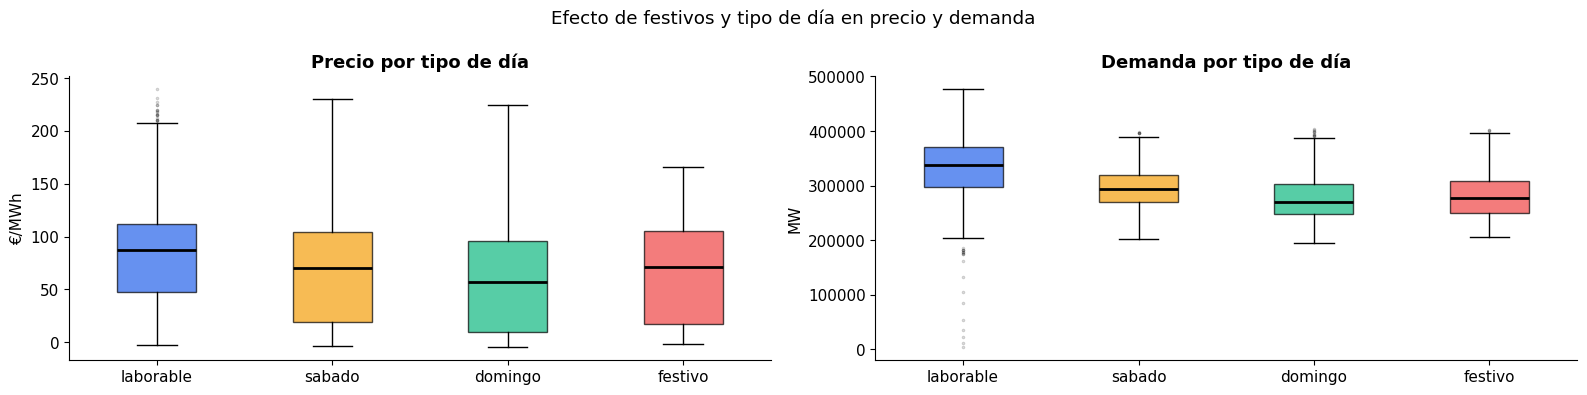


Media precio y demanda por tipo de día:
           precio_eur_mwh  demanda_mw
tipo_dia                             
domingo              58.1    276941.6
festivo              66.4    280251.3
laborable            80.3    334803.1
sabado               65.3    296173.0


In [27]:
# ── Efecto festivos en el precio ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Efecto de festivos y tipo de día en precio y demanda')

# Boxplot precio por tipo de día
orden = ['laborable', 'sabado', 'domingo', 'festivo']
data_boxplot = [df[df['tipo_dia'] == t]['precio_eur_mwh'].dropna() for t in orden]
bp0 = axes[0].boxplot(data_boxplot, labels=orden, patch_artist=True,
                      medianprops=dict(color='black', lw=2),
                      flierprops=dict(marker='.', alpha=0.2, markersize=3))
for patch, color in zip(bp0['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('€/MWh')
axes[0].set_title('Precio por tipo de día')

data_boxplot2 = [df[df['tipo_dia'] == t]['demanda_mw'].dropna() for t in orden]
bp1 = axes[1].boxplot(data_boxplot2, labels=orden, patch_artist=True,
                      medianprops=dict(color='black', lw=2),
                      flierprops=dict(marker='.', alpha=0.2, markersize=3))
for patch, color in zip(bp1['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('MW')
axes[1].set_title('Demanda por tipo de día')

plt.tight_layout()
plt.savefig('/eda_12_festivos.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print('\nMedia precio y demanda por tipo de día:')
print(df.groupby('tipo_dia')[['precio_eur_mwh','demanda_mw']].mean().round(1))

---
## 7. Análisis de variables meteorológicas

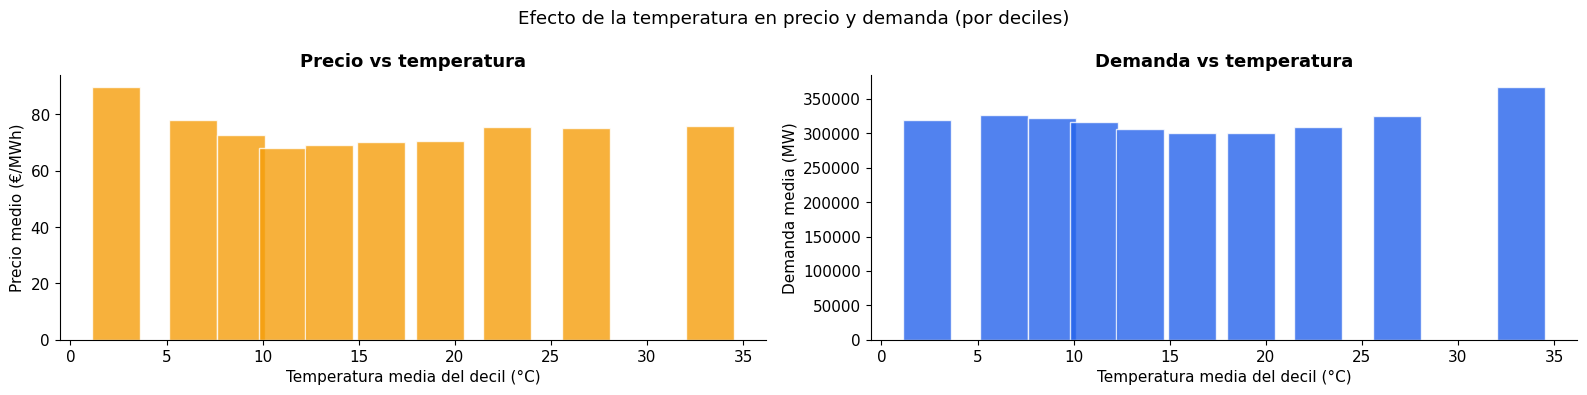

Temperatura de mínima demanda: ~16.2°C (zona de confort térmico)


In [29]:
# ── Precio medio por decil de temperatura ─────────────────────────────────────
df['decil_temp'] = pd.qcut(df['temperatura_c'], q=10, labels=False)
precio_por_temp  = df.groupby('decil_temp')[['precio_eur_mwh','demanda_mw']].mean()
temp_por_decil   = df.groupby('decil_temp')['temperatura_c'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Efecto de la temperatura en precio y demanda (por deciles)')

axes[0].bar(temp_por_decil.values, precio_por_temp['precio_eur_mwh'].values,
            width=2.5, color=COLORS[1], alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Temperatura media del decil (°C)')
axes[0].set_ylabel('Precio medio (€/MWh)')
axes[0].set_title('Precio vs temperatura')

axes[1].bar(temp_por_decil.values, precio_por_temp['demanda_mw'].values,
            width=2.5, color=COLORS[0], alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Temperatura media del decil (°C)')
axes[1].set_ylabel('Demanda media (MW)')
axes[1].set_title('Demanda vs temperatura')

plt.tight_layout()
plt.savefig('/eda_13_temperatura_efecto.png', dpi=150, bbox_inches='tight')
plt.show()

# Temperatura de confort (mínima demanda)
idx_min = precio_por_temp['demanda_mw'].idxmin()
print(f'Temperatura de mínima demanda: ~{temp_por_decil[idx_min]:.1f}°C (zona de confort térmico)')

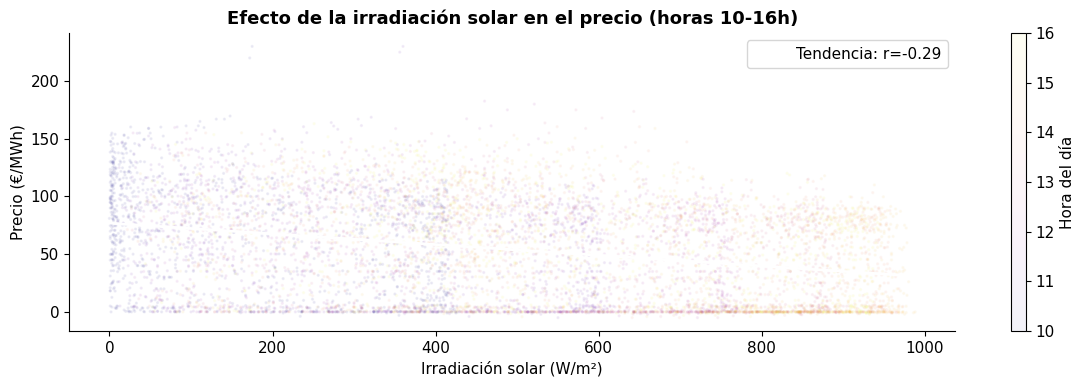

In [30]:
# ── Efecto irradiación solar en precio ────────────────────────────────────────
# La solar reduce el precio spot al aumentar oferta renovable
df_dia = df.between_time('10:00','16:00')  # Horas de mayor irradiación

fig, ax = plt.subplots(figsize=(12, 4))
sc = ax.scatter(df_dia['irradiacion_wm2'], df_dia['precio_eur_mwh'],
                alpha=0.05, s=2, c=df_dia['hora'], cmap='plasma')
plt.colorbar(sc, ax=ax, label='Hora del día')

# Tendencia
mask_valid = df_dia['irradiacion_wm2'].notna() & df_dia['precio_eur_mwh'].notna()
m, b = np.polyfit(df_dia.loc[mask_valid,'irradiacion_wm2'],
                  df_dia.loc[mask_valid,'precio_eur_mwh'], 1)
x_l = np.linspace(0, df_dia['irradiacion_wm2'].max(), 100)
ax.plot(x_l, m*x_l + b, color='white', lw=2,
        label=f'Tendencia: r={df_dia[["irradiacion_wm2","precio_eur_mwh"]].corr().iloc[0,1]:.2f}')
ax.set_xlabel('Irradiación solar (W/m²)')
ax.set_ylabel('Precio (€/MWh)')
ax.set_title('Efecto de la irradiación solar en el precio (horas 10-16h)')
ax.legend()
plt.tight_layout()
plt.savefig('/eda_14_irradiacion_precio.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Descomposición de la serie temporal

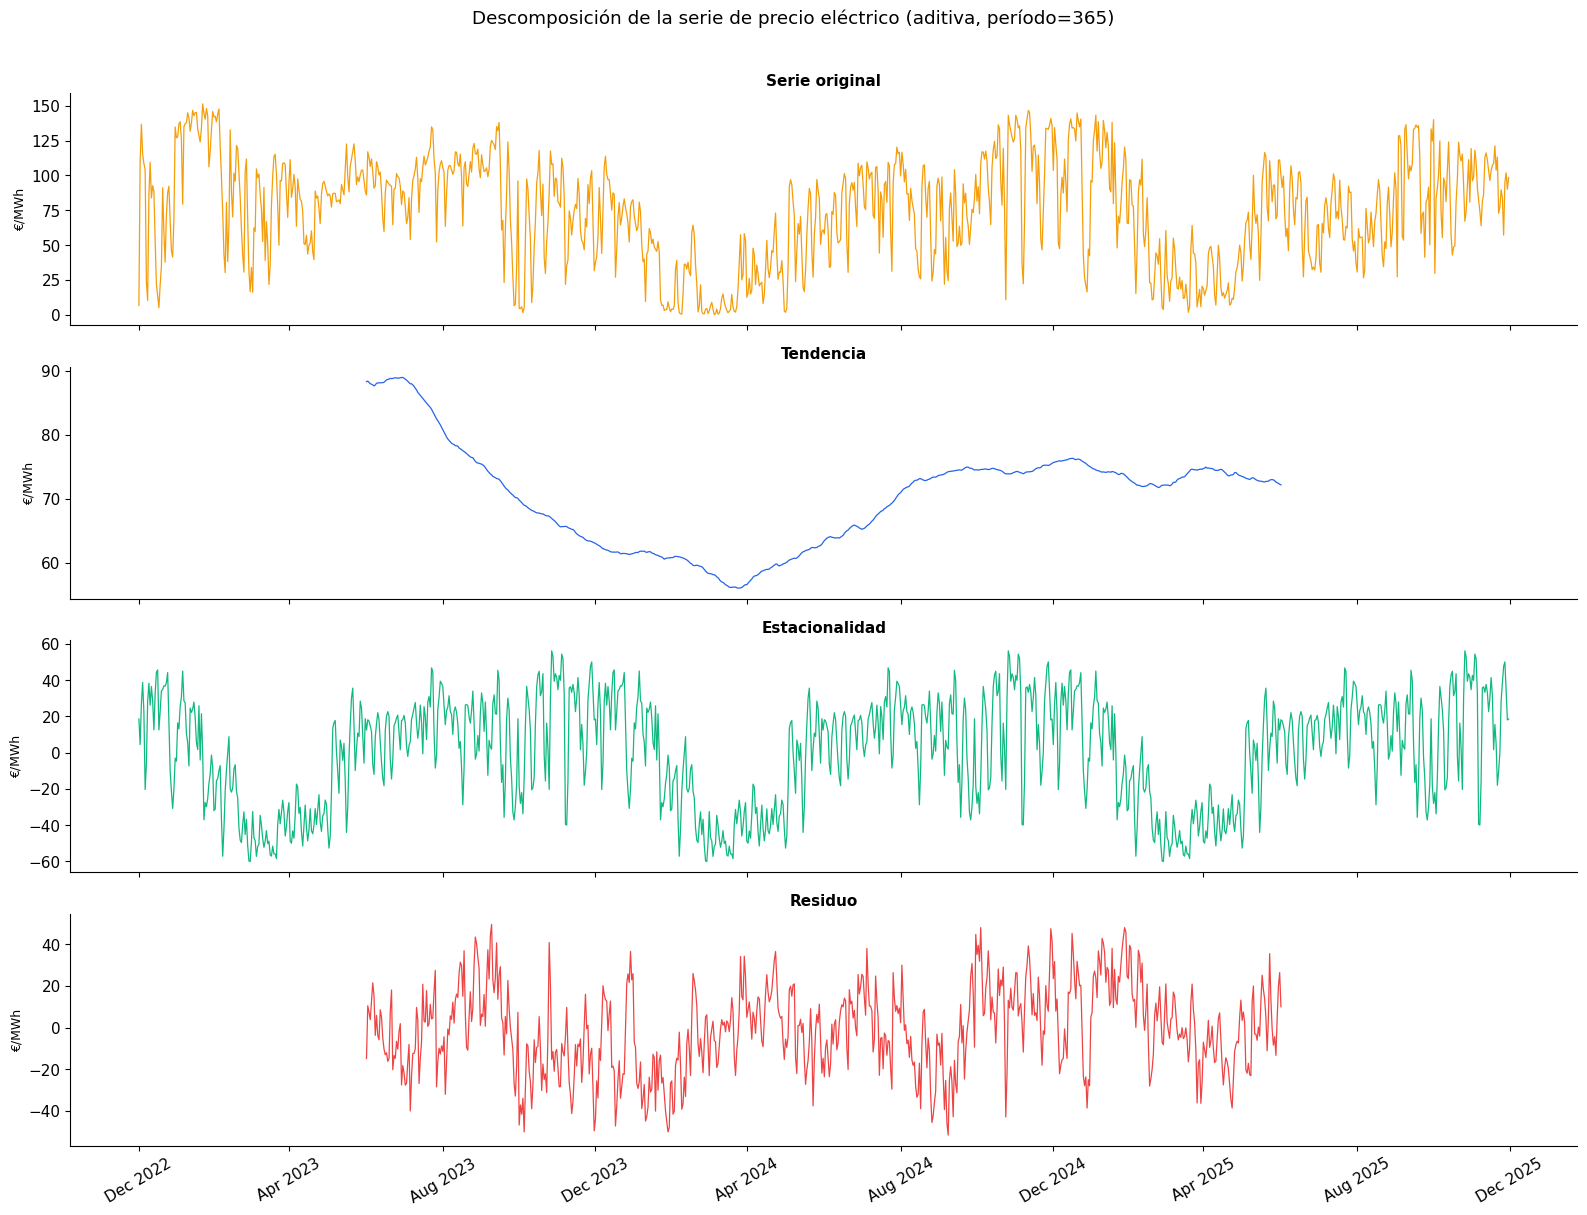

In [32]:
# ── Descomposición STL simplificada con seasonal_decompose ────────────────────
# Usamos datos diarios para mayor claridad visual
precio_diario = df['precio_eur_mwh'].resample('D').mean().dropna()

decomp = seasonal_decompose(precio_diario, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Descomposición de la serie de precio eléctrico (aditiva, período=365)', y=1.01)

componentes = [
    (precio_diario,      'Serie original',  COLORS[1]),
    (decomp.trend,       'Tendencia',        COLORS[0]),
    (decomp.seasonal,    'Estacionalidad',   COLORS[2]),
    (decomp.resid,       'Residuo',          COLORS[3]),
]

for ax, (serie, titulo, color) in zip(axes, componentes):
    ax.plot(serie.index, serie.values, color=color, lw=0.9)
    ax.set_ylabel('€/MWh', fontsize=9)
    ax.set_title(titulo, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('/eda_15_descomposicion.png', dpi=150, bbox_inches='tight')
plt.show()

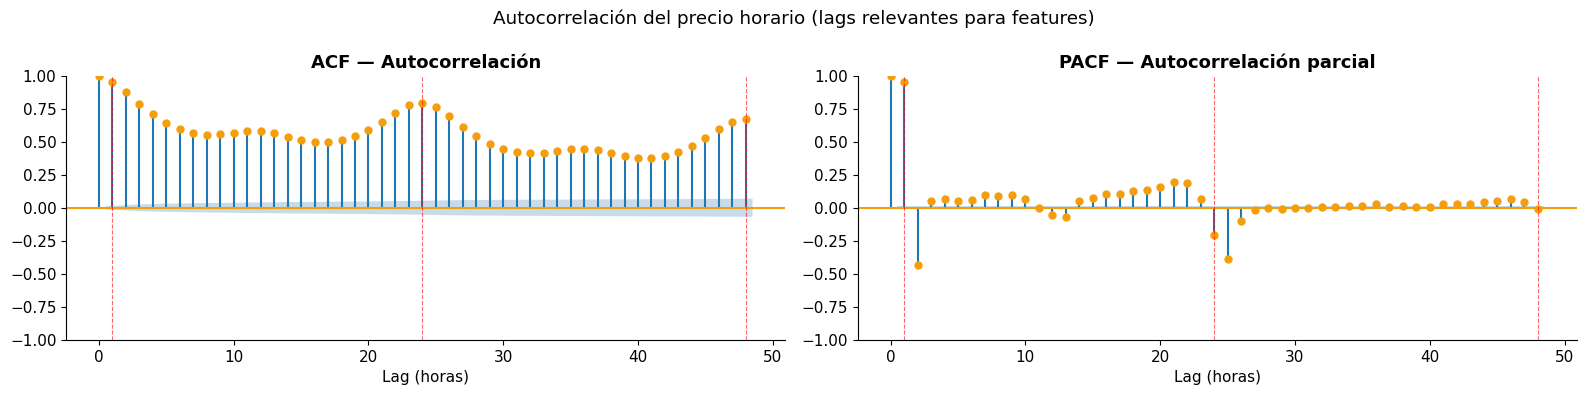

Correlación precio con sus propios lags:
  Lag   1h (0.0d): r = 0.955
  Lag   2h (0.1d): r = 0.875
  Lag   3h (0.1d): r = 0.787
  Lag  24h (1.0d): r = 0.798
  Lag  48h (2.0d): r = 0.672
  Lag 168h (7.0d): r = 0.621


In [33]:
# ── Autocorrelación — lags relevantes para el modelo ─────────────────────────
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Autocorrelación del precio horario (lags relevantes para features)')

plot_acf(df['precio_eur_mwh'].dropna(),  lags=48, ax=axes[0], color=COLORS[1], alpha=0.05)
plot_pacf(df['precio_eur_mwh'].dropna(), lags=48, ax=axes[1], color=COLORS[1], alpha=0.05, method='ywm')

axes[0].set_title('ACF — Autocorrelación')
axes[1].set_title('PACF — Autocorrelación parcial')

# Marcar lags clave
for ax in axes:
    for lag in [1, 24, 48]:
        ax.axvline(lag, color='red', ls='--', lw=0.8, alpha=0.6)
    ax.set_xlabel('Lag (horas)')

plt.tight_layout()
plt.savefig('/eda_16_autocorrelacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlación con lags específicos
print('Correlación precio con sus propios lags:')
for lag in [1, 2, 3, 24, 48, 168]:
    r = df['precio_eur_mwh'].autocorr(lag=lag)
    print(f'  Lag {lag:3d}h ({lag/24:.1f}d): r = {r:.3f}')

---
## 9. Conclusiones del EDA

In [37]:
print('''
1. DISTRIBUCIÓN DEL PRECIO
   - Distribución casi simétrica (skewness=-0.12) y platicúrtica (kurtosis=-0.87)
   - Ausencia de cola derecha pronunciada: el mercado 2023-2025 fue relativamente
     estable tras el shock energético de 2022
   - Presencia de precios negativos (concentrados en horas solares de 2024-2025):
     fenómeno estructural por sobreoferta fotovoltaica, no errores de datos
   - Outliers altos identificados y explicados: eventos reales de mercado
     (olas de frío en enero-febrero, caída solar estacional en octubre 2025)
   → Implicación: NO se aplica transformación logarítmica. Se usará
     StandardScaler sobre features y MinMaxScaler sobre el target para los modelos.

2. PATRONES TEMPORALES
   - Perfil horario bimodal en demanda (picos 10h y 20h en laborables)
   - Precio mínimo en horas solares (12-15h), no en madrugada: cambio estructural
     del mercado por penetración fotovoltaica. Relevante para el consumidor final.
   - Efecto día de semana pronunciado: laborables > fin de semana en demanda y precio
   - Estacionalidad anual clara: máximos en invierno y verano, mínimos en primavera
   → Implicación: hora, dia_semana y mes son features esenciales con encoding cíclico

3. VARIABLES MÁS CORRELACIONADAS CON EL PRECIO
   - Hora del día: correlación cíclica fuerte (encoding sin/cos imprescindible)
   - Irradiación solar: correlación negativa — más solar implica menor precio spot
   - Temperatura: relación en U (frío y calor incrementan precio)
   - dias_hasta_festivo: correlación lineal baja (r=0.01) pero relación no lineal
     real confirmada — festivos reducen precio un 19% respecto a vísperas
   → Implicación: incluir irradiacion_wm2, temperatura y flags de festivo/víspera/post

4. AUTOCORRELACIÓN
   - ACF significativa en lag=1h, lag=24h y lag=168h (semana anterior)
   - El precio de ayer a la misma hora y el de la semana pasada son los mejores
     predictores univariantes del precio actual
   → Implicación: lags 1, 24 y 168 son features imprescindibles en el modelo

5. OUTLIERS Y CALIDAD DE DATOS
   - 12 outliers de precio (0.05%): todos explicados por eventos reales de mercado
   - 0 nulos tras imputación
   - Decisión: mantener todos los outliers con documentación en el TFM
   → Dataset listo para modelado: 26.284 filas × 27 columnas, granularidad horaria
''')


1. DISTRIBUCIÓN DEL PRECIO
   - Distribución casi simétrica (skewness=-0.12) y platicúrtica (kurtosis=-0.87)
   - Ausencia de cola derecha pronunciada: el mercado 2023-2025 fue relativamente
     estable tras el shock energético de 2022
   - Presencia de precios negativos (concentrados en horas solares de 2024-2025):
     fenómeno estructural por sobreoferta fotovoltaica, no errores de datos
   - Outliers altos identificados y explicados: eventos reales de mercado
     (olas de frío en enero-febrero, caída solar estacional en octubre 2025)
   → Implicación: NO se aplica transformación logarítmica. Se usará
     StandardScaler sobre features y MinMaxScaler sobre el target para los modelos.

2. PATRONES TEMPORALES
   - Perfil horario bimodal en demanda (picos 10h y 20h en laborables)
   - Precio mínimo en horas solares (12-15h), no en madrugada: cambio estructural
     del mercado por penetración fotovoltaica. Relevante para el consumidor final.
   - Efecto día de semana pronunciado: la